# The geometry of softmax

Sofmax converts arbitrary score vectors with real values to discrete probability distributions. But what does it do geometrically?

Softmax is invariant to adding the same value to all elements of the input vector:

$$\sigma(\mathbf{z} + c\mathbf{1})_i = \frac{e^{z_i + c}}{\sum_{j=1}^K e^{z_j + c}} = \frac{e^c e^{z_i}}{e^c \sum_{j=1}^K e^{z_j}} = \sigma(\mathbf{z})_i$$

It can also be shown that if two vectors map to the same probability distribution via softmax, they differ only in a constant added elementwise to one of them. Therefore, "softmax level sets" (sets of points in the space of logit values mapping to the same probability distribution) are straight lines.

In 2-D, these lines are parallel to the $y = x$ line, i.e. they form a 45 degree angle with the x-axis. In multidimensional spaces, they are parallel to the span of the $(1, 1, ..., 1)$ vector.

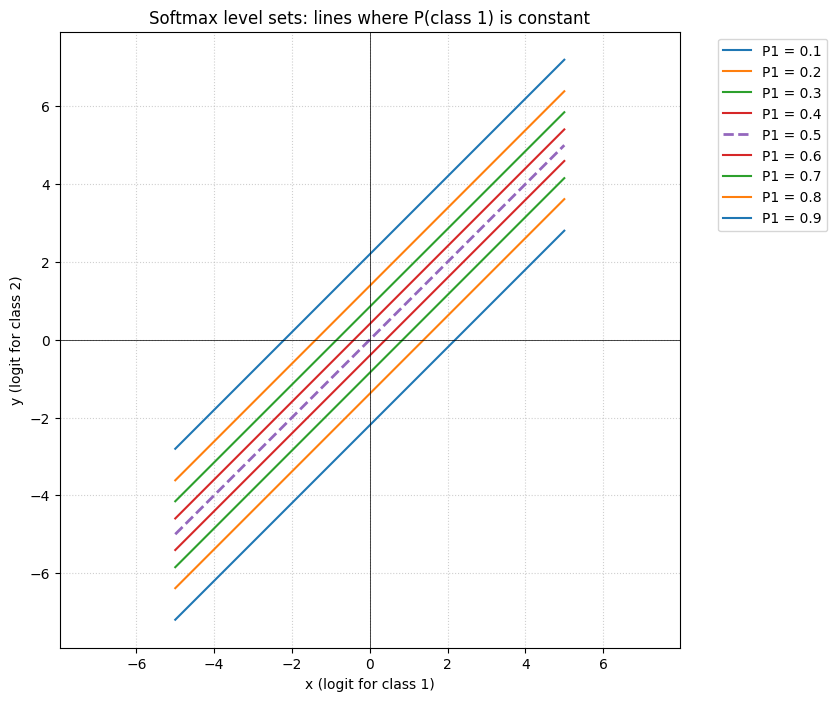

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def plot_softmax_lines():
    x = np.linspace(-5, 5, 100)

    # Probabilities to plot (P1 values)
    # 0.5 is the center (y=x)
    probs = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

    plt.figure(figsize=(8, 8))

    # Use the modern colormap access to avoid deprecation warnings
    colors = plt.colormaps['tab10']

    for i, p in enumerate(probs):
        # For softmax(x, y), P1 = exp(x) / (exp(x) + exp(y))
        # This simplifies to log(P1 / (1-P1)) = x - y  =>  y = x - logit
        logit = np.log(p / (1 - p))
        y = x - logit

        # Use same color for symmetric probabilities (p and 1-p)
        color_idx = i if i <= len(probs)//2 else len(probs) - 1 - i
        label = f'P1 = {p:.1f}'
        linestyle = '-' if p != 0.5 else '--'
        linewidth = 2 if p == 0.5 else 1.5

        plt.plot(x, y, label=label, color=colors(color_idx), linestyle=linestyle, linewidth=linewidth)

    plt.axhline(0, color='black', linewidth=0.5)
    plt.axvline(0, color='black', linewidth=0.5)
    plt.title('Softmax level sets: lines where P(class 1) is constant')
    plt.xlabel('x (logit for class 1)')
    plt.ylabel('y (logit for class 2)')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.axis('equal')
    plt.show()

plot_softmax_lines()

Softmax maps all points to the so-called probability simplex: a K-1-dimensional subset of the K-dimensional space where the coordinates sum to 1. It is a line segment in 2D, a triangle in 3D, a tetrahedron in 4D, etc. Lines that are further away from the span of $(1, 1, ..., 1)$ (the "main diagonal") are mapped to the points closer to the boundary of the simplex.

However, the boundary can only be reached if some of the logits reach positive or negative infinity, i.e. never. Therefore the logit space gets more and more compressed in the softmax representation the further away we get from the main diagonal.

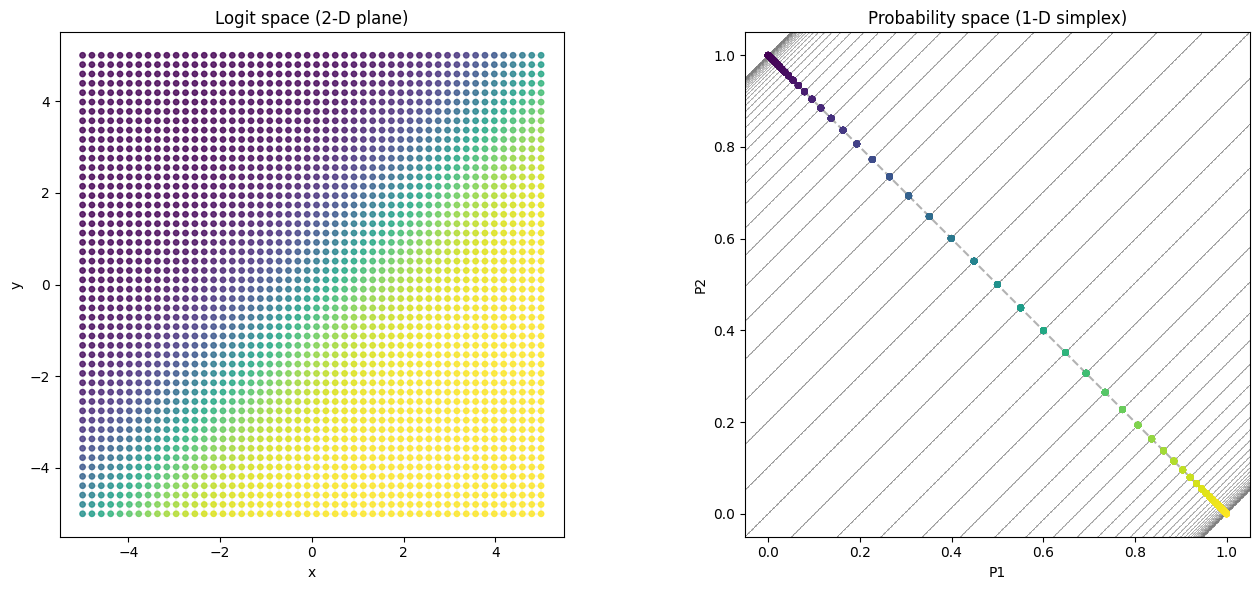

In [10]:
def plot_softmax_warping():
    # 1. Create a denser grid in logit space
    span = 5
    n_points = 50
    x = np.linspace(-span, span, n_points)
    y = np.linspace(-span, span, n_points)
    xv, yv = np.meshgrid(x, y)

    # 2. Apply Softmax
    ex = np.exp(xv)
    ey = np.exp(yv)
    p1 = ex / (ex + ey)
    p2 = ey / (ex + ey)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    # Left Plot: Logit Space
    ax1.scatter(xv, yv, c=p1, cmap='viridis', s=15, alpha=0.8, zorder=3)
    for i in range(len(x)):
        ax1.plot(xv[i, :], yv[i, :], 'k-', alpha=0.05)
        ax1.plot(xv[:, i], yv[:, i], 'k-', alpha=0.05)

    ax1.set_title('Logit space (2-D plane)')
    ax1.set_xlabel('x')
    ax1.set_ylabel('y')
    ax1.grid(False) # Remove grid
    ax1.set_aspect('equal')

    # Right Plot: Probability Space
    ax2.plot([0, 1], [1, 0], 'k--', alpha=0.3, zorder=1)

    # Add lines parallel to y=x for each point
    x_range = np.linspace(-0.1, 1.1, 10)
    for i in range(p1.shape[0]):
        for j in range(p1.shape[1]):
            offset = p2[i, j] - p1[i, j]
            ax2.plot(x_range, x_range + offset, color='grey', linestyle=':', linewidth=0.3, alpha=0.15)

    ax2.scatter(p1, p2, c=p1, cmap='viridis', s=15, alpha=0.8, zorder=3)

    ax2.set_title('Probability space (1-D simplex)')
    ax2.set_xlabel('P1')
    ax2.set_ylabel('P2')
    ax2.set_xlim(-0.05, 1.05)
    ax2.set_ylim(-0.05, 1.05)
    ax2.set_aspect('equal')
    ax2.grid(False) # Remove grid

    plt.tight_layout()
    plt.show()

plot_softmax_warping()

Since softmax does not care about parallel translations, we can always preprocess logits by subtracting, e.g., the average value of the inputs. This will project the inputs on a lower-dimensional subspace where coordinates sum to 0 ($y = -x$ in 2-D). Softmax will then shrink this K-1-dimensional subspace to fit inside the K-1-dimensional probability simplex.

(In practice we instead normally subtract the maximum coordinate to avoid large $\exp(x_i)$ values, which geometrically means projecting on a K-1-dimensional surface where the maximum coordinate is 0.)

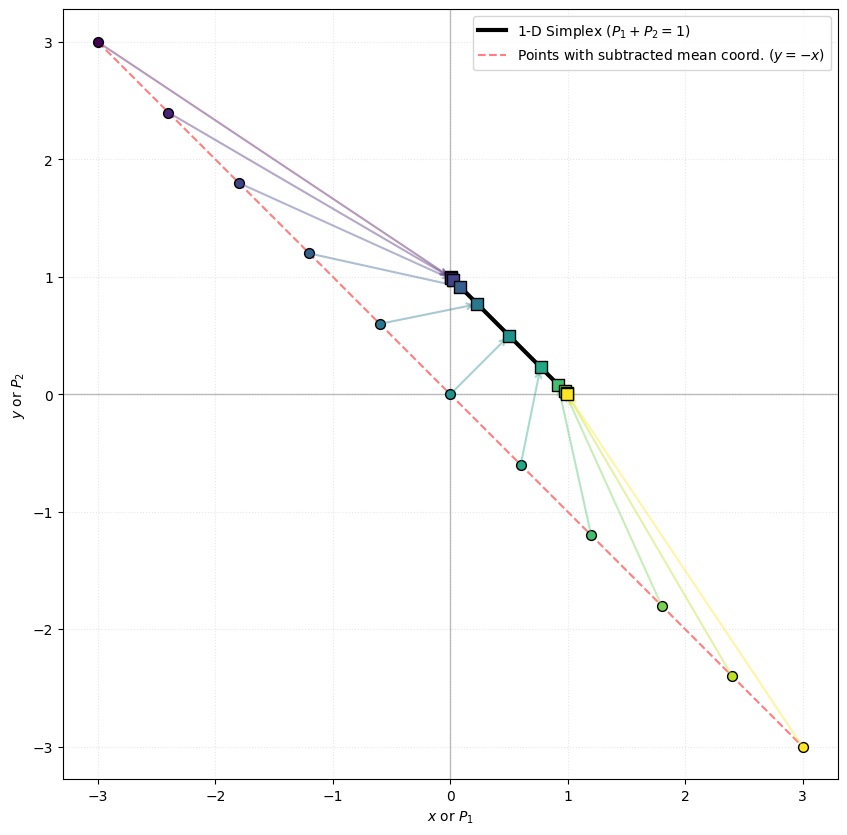

In [15]:
def plot_unified_mapping():
    # 1. Define the Max Variance line in logit space (y = -x)
    x_logits = np.linspace(-3, 3, 11)
    y_logits = -x_logits

    # 2. Compute Softmax probabilities
    ex = np.exp(x_logits)
    ey = np.exp(y_logits)
    p1 = ex / (ex + ey)
    p2 = ey / (ex + ey)

    plt.figure(figsize=(10, 10))

    # Plot the Simplex (P1 + P2 = 1)
    plt.plot([0, 1], [1, 0], color='black', linewidth=3, label='1-D Simplex ($P_1+P_2=1$)', zorder=1)

    # Plot the Logit Line (y = -x)
    plt.plot(x_logits, y_logits, 'r--', alpha=0.5, label='Points with subtracted mean coord. ($y=-x$)', zorder=1)

    # Plot points and mapping arrows
    colors = plt.colormaps['viridis'](np.linspace(0, 1, len(x_logits)))

    for i in range(len(x_logits)):
        # Logit point
        plt.scatter(x_logits[i], y_logits[i], color=colors[i], edgecolors='black', s=50, zorder=3)

        # Simplex point
        plt.scatter(p1[i], p2[i], color=colors[i], edgecolors='black', marker='s', s=80, zorder=4)

        # Mapping arrow from (x,y) to (p1, p2)
        plt.annotate('', xy=(p1[i], p2[i]), xytext=(x_logits[i], y_logits[i]),
                     arrowprops=dict(arrowstyle="->", color=colors[i], alpha=0.4, lw=1.5))

    # Aesthetics
    plt.axhline(0, color='grey', lw=1, alpha=0.5)
    plt.axvline(0, color='grey', lw=1, alpha=0.5)
    # plt.title('Unified View: Mapping $y=-x$ Logits to the Probability Simplex')
    plt.xlabel('$x$ or $P_1$')
    plt.ylabel('$y$ or $P_2$')
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.3)
    plt.axis('equal')
    plt.show()

plot_unified_mapping()